# Figure Experiments (Circuits)

## 1) Concept Cells via Cross-Context Linear Decoding

This notebook starts with a concept-cell metric based on **cross-context generalization**.

For each target concept (`A_i` or `B_j`):
- Pick one opposite-attribute concept for training context (for `A_i`, fix a `B_j`; for `B_j`, fix an `A_i`).
- Build training input deterministically with exactly two blocks: target pair and one non-target pair (one block each).
- Train a linear decoder on that context.
- Test uses random `make_input` episodes that exclude the training opposite context (e.g., all pairs with `B != B_train`), with target marginal set to 0.5.

We compare decoding accuracy from `MTL-sensory` vs `MTL-semantic`.


In [1]:
import os

import numpy as np
import torch

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from src.utils.plotting import compare_distributions_12

from Figure_experiments_circuits import (
    run_cross_context_concept_cell_experiment,
    run_increase_overlap_experiment,
    run_synaptic_engrams_experiment,
    seed_everything,
)

blue = '#00AEEF'
red = '#F15A2A'

blue_yellow = LinearSegmentedColormap.from_list(
    "blue_yellow", ["#0073B7", "#FFD23F"]
)


green = '#00A651'
orange = '#F7941D'

In [2]:
# Experiment config
seed_everything(0)

recording_parameters = {
    "regions": ["mtl_semantic", "mtl_sensory"],
    "rate_activity": 1,
    "connections": [],
    "rate_connectivity": np.inf,
}

train_within_day_stats = {
    "mean_duration": 1,
    "num_swaps": 8,
}

test_sampling_params = {
    "num_days": 1,
    "day_length": 200,
    "mean_duration": 5,
    "fixed_duration": True,
    "num_swaps": 8,
}

base_latent_specs = {
    "num": 2,
    "total_sizes": [50, 50],
    "act_sizes": [10, 10],
    "dims": [5, 5],
    "prob_list": [1 / 25 for _ in range(25)],
}

NUM_REPEATS = 10
MAX_TEST_ATTEMPTS = 25

checkpoint_path = "checkpoints/network_3_B.pt"
# checkpoint_path = "checkpoints/network_4_blocked_best.pt"
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(
        f"Missing checkpoint at {checkpoint_path}. "
        "Run training first or update checkpoint_path."
    )

network = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
network.frozen = True


In [3]:
results_df = run_cross_context_concept_cell_experiment(
    net=network,
    recording_parameters=recording_parameters,
    base_latent_specs=base_latent_specs,
    train_within_day_stats=train_within_day_stats,
    test_sampling_params=test_sampling_params,
    num_repeats=NUM_REPEATS,
    seed=0,
    max_test_attempts=MAX_TEST_ATTEMPTS,
)

Running concept A1...
Running concept A2...
Running concept A3...
Running concept A4...
Running concept A5...
Running concept B1...
Running concept B2...
Running concept B3...
Running concept B4...
Running concept B5...


In [4]:
summary_by_region = (
    results_df.groupby("region")["accuracy"]
    .agg(["mean", "std", "count"])
    .assign(sem=lambda d: d["std"] / np.sqrt(d["count"]))
)

summary_by_concept_region = (
    results_df.groupby(["concept", "region"])["accuracy"]
    .agg(["mean", "std", "count"])
    .assign(sem=lambda d: d["std"] / np.sqrt(d["count"]))
    .reset_index()
)

print("Summary across all concepts (per subregion):")
display(summary_by_region)

Summary across all concepts (per subregion):


,mean,std,count,sem
region,,,,
MTL-semantic,0.99705,0.004210,100,0.000421
MTL-sensory,0.75385,0.058826,100,0.005883


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


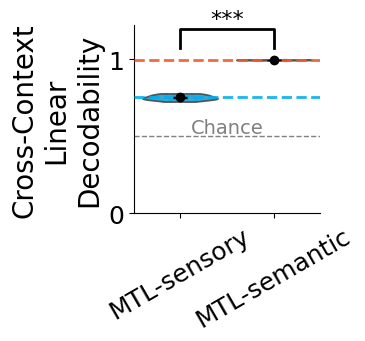

In [5]:
# Cross-context linear decodability distributions (concept-level)
concept_level = (
    results_df.groupby(["concept", "region"], as_index=False)["accuracy"]
    .mean()
)

dist1 = (
    'MTL-sensory',
    concept_level.loc[concept_level['region'] == 'MTL-sensory', 'accuracy'].to_numpy(),
)
dist2 = (
    'MTL-semantic',
    concept_level.loc[concept_level['region'] == 'MTL-semantic', 'accuracy'].to_numpy(),
)

palette = {
    'MTL-sensory': blue,
    'MTL-semantic': red,
}

compare_distributions_12(dist1, dist2, palette)
plt.tight_layout()
sns.despine()

plt.ylabel('Cross-Context\nLinear\nDecodability', fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([0., 1], fontsize=18)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.text(0.5, 0.52, 'Chance', color='gray', fontsize=14, ha='center')
plt.tight_layout()
sns.despine()


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


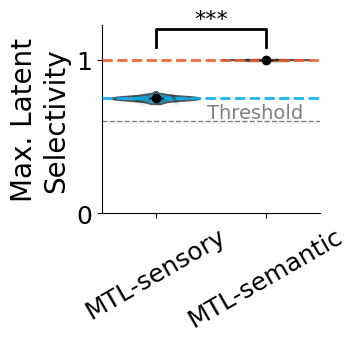

In [6]:
sel_threshold = 0.6

max_sel_sensory = network.selectivity_mtl_sensory.max(axis=1).values
max_sel_sensory = max_sel_sensory[max_sel_sensory >= 0.6]

max_sel_semantic = network.selectivity_mtl_semantic.max(axis=1).values
max_sel_semantic = max_sel_semantic[max_sel_semantic >= 0.6]


dist1 = ('MTL-sensory', max_sel_sensory)
dist2 = ('MTL-semantic', max_sel_semantic)

palette = {
    'MTL-sensory': blue,
    'MTL-semantic': red,
}

compare_distributions_12(dist1, dist2, palette)
plt.tight_layout()
sns.despine()

plt.ylabel('Max. Latent\nSelectivity', fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([0, 1], fontsize=18)
plt.axhline(0.6, color='gray', linestyle='--', linewidth=1)
plt.text(0.9, 0.62, 'Threshold', color='gray', fontsize=14, ha='center')
plt.tight_layout()
sns.despine()

/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


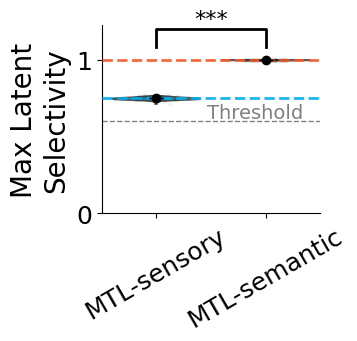

In [7]:
# Recompute selectivity from a long no-consolidation test day (Figure 3 style)
from copy import deepcopy
import torch.nn.functional as F
from src.utils.general import LatentSpace, make_input, get_ordered_indices

seed_everything(0)

long_test_day_params = {
    "num_days": 1,
    "day_length": 10000,
    "mean_duration": 5,
    "fixed_duration": True,
    "num_swaps": 4,
}

latent_specs_long_test = dict(base_latent_specs)
latent_specs_long_test["prob_list"] = [
    1 / (latent_specs_long_test["dims"][0] * latent_specs_long_test["dims"][1])
    for _ in range(latent_specs_long_test["dims"][0] * latent_specs_long_test["dims"][1])
]
long_test_day_params["latent_space"] = LatentSpace(**latent_specs_long_test)

network_long_test = deepcopy(network)
network_long_test.frozen = True
network_long_test.init_recordings(recording_parameters)

input_long_test, _, input_latents_long_test = make_input(**long_test_day_params)
with torch.no_grad():
    network_long_test(input_long_test[0], debug=False)

mtl_sensory_recordings_long_test = torch.stack(
    network_long_test.activity_recordings["mtl_sensory"], dim=0
)[network_long_test.awake_indices]
mtl_semantic_recordings_long_test = torch.stack(
    network_long_test.activity_recordings["mtl_semantic"], dim=0
)[network_long_test.awake_indices]

latent_A_one_hot_long_test = F.one_hot(
    input_latents_long_test[:, :, 0].long(),
    num_classes=latent_specs_long_test["dims"][0],
)
latent_B_one_hot_long_test = F.one_hot(
    input_latents_long_test[:, :, 1].long(),
    num_classes=latent_specs_long_test["dims"][1],
)
latent_AB_one_hot_long_test = torch.cat(
    (latent_A_one_hot_long_test, latent_B_one_hot_long_test), axis=2
)

selectivity_mtl_sensory_long_test, ordered_indices_mtl_sensory_long_test = get_ordered_indices(
    mtl_sensory_recordings_long_test,
    latent_AB_one_hot_long_test,
    assembly_size=5,
)
selectivity_mtl_semantic_long_test, ordered_indices_mtl_semantic_long_test = get_ordered_indices(
    mtl_semantic_recordings_long_test,
    latent_AB_one_hot_long_test,
    assembly_size=5,
)

max_selectivity_mtl_sensory_long_test = selectivity_mtl_sensory_long_test.max(axis=1).values
max_selectivity_mtl_semantic_long_test = selectivity_mtl_semantic_long_test.max(axis=1).values

selectivity_threshold = sel_threshold if 'sel_threshold' in globals() else 0.75
max_selectivity_mtl_sensory_long_test = max_selectivity_mtl_sensory_long_test[
    max_selectivity_mtl_sensory_long_test >= selectivity_threshold
]
max_selectivity_mtl_semantic_long_test = max_selectivity_mtl_semantic_long_test[
    max_selectivity_mtl_semantic_long_test >= selectivity_threshold
]

dist1 = ('MTL-sensory', max_selectivity_mtl_sensory_long_test)
dist2 = ('MTL-semantic', max_selectivity_mtl_semantic_long_test)

palette = {
    'MTL-sensory': blue,
    'MTL-semantic': red,
}

compare_distributions_12(dist1, dist2, palette)
plt.tight_layout()
sns.despine()

plt.ylabel('Max Latent\nSelectivity', fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([0, 1], fontsize=18)
plt.axhline(selectivity_threshold, color='gray', linestyle='--', linewidth=1)
plt.text(0.9, float(selectivity_threshold) + 0.02, 'Threshold', color='gray', fontsize=14, ha='center')
plt.tight_layout()
sns.despine()


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


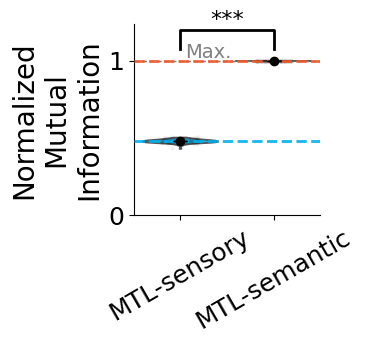

In [8]:
# Mutual information distributions (most-selective latent, thresholded units)
from src.utils.general import get_mutual_information_most_selective_latent

mutual_information_mtl_sensory = get_mutual_information_most_selective_latent(
    recordings=mtl_sensory_recordings_long_test,
    latents=latent_AB_one_hot_long_test,
    selectivity_threshold=selectivity_threshold,
)
mutual_information_mtl_semantic = get_mutual_information_most_selective_latent(
    recordings=mtl_semantic_recordings_long_test,
    latents=latent_AB_one_hot_long_test,
    selectivity_threshold=selectivity_threshold,
)

dist1 = (
    'MTL-sensory',
    mutual_information_mtl_sensory['normalized_mutual_information'].detach().cpu().numpy(),
)
dist2 = (
    'MTL-semantic',
    mutual_information_mtl_semantic['normalized_mutual_information'].detach().cpu().numpy(),
)

palette = {
    'MTL-sensory': blue,
    'MTL-semantic': red,
}

compare_distributions_12(dist1, dist2, palette)
plt.tight_layout()
sns.despine()

plt.ylabel('Normalized\nMutual\nInformation', fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([0, 1], fontsize=18)
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1)
plt.text(0.3, 1.02, 'Max.', color='gray', fontsize=14, ha='center')
plt.tight_layout()
sns.despine()


## 2) Increase In Overlap

TODO: add overlap manipulation experiment.


In [9]:
# Increase in overlap config + run (paper-like scale)
from copy import deepcopy
from network_parameters import network_parameters

seed_everything(0)

recording_parameters_overlap = {
    "regions": ["sen", "mtl_sensory", "mtl", "ctx"],
    "rate_activity": 1,
    "connections": [],
    "rate_connectivity": np.inf,
}

network_parameters_overlap = deepcopy(network_parameters)
network_parameters_overlap["duration_phase_A"] = 0  # enable semantic replay from the start

overlap_config = {
    "num_objects": 128,
    "num_scenes": 4,
    "num_days_train": 1,
    "presentations_per_object": 1,
    "train_mean_duration": 5,
    "train_num_swaps": 4,
    "total_sizes": (80, 20),  # ignored when auto_allocate_mtl_sensory=True
    "act_sizes": (10, 10),
    "latent_random_neurons": False,
    "auto_allocate_mtl_sensory": True,
    "consolidation_sleep_cycles": 1,
    "cue_num_swaps": 4,
    "condition_mtl_on_cue": True,
    "seed": 1,
    "duration_phase_A": 0,
    "sleep_duration_A": 500,
    "sleep_duration_B": 50,
}

overlap_results = run_increase_overlap_experiment(
    network_parameters=network_parameters_overlap,
    recording_parameters=recording_parameters_overlap,
    stop_after="recall",
    **overlap_config,
)


In [10]:
net = deepcopy(overlap_results["network"])

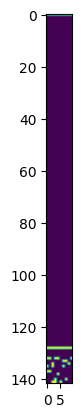

In [11]:
mtl_0 = torch.zeros(net.mtl_size)
mtl_0[:10] = 1

mtl_1 = net.activation(net.mtl_mtl @ mtl_0, "mtl")[0]

#plt.imshow(net.pattern_complete("mtl", mtl_0).reshape((-1, 10)))
plt.imshow(mtl_1.reshape((-1, 10)))

Text(0.5, 0, 'Time')

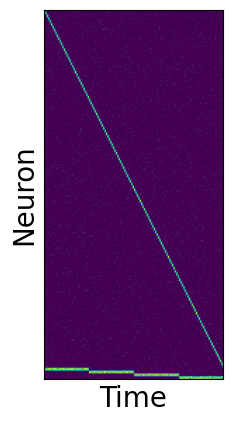

In [12]:
plt.imshow(torch.stack(overlap_results["network"].activity_recordings["mtl"], axis=0)[overlap_results["network"].awake_indices].T[:overlap_results["network"].mtl_sensory_size])


plt.yticks([], fontsize=16)
plt.xticks([], fontsize=18)
plt.ylabel("Neuron", fontsize=20)
plt.xlabel("Time", fontsize=20)

In [13]:
overlap_summary_df = overlap_results["summary_df"]
overlap_trial_df = overlap_results["overlap_df"]
overlap_network = overlap_results["network"]

display(overlap_summary_df)


# Scene decoding accuracy from MTL sensory B-subspaces (pre vs post)
scene_decoding_df = overlap_results["scene_decoding_df"]
scene_decoding_summary_df = overlap_results["scene_decoding_summary_df"]

display(scene_decoding_summary_df)

,region,phase,mean,std,count,sem
0,CTX,post,0.495005,0.036972,128,0.003268
1,CTX,pre,0.254212,0.033769,128,0.002985
2,MTL,post,0.553971,0.014626,128,0.001293
3,MTL,pre,0.316134,0.020489,128,0.001811


,phase,accuracy,std,count,sem
0,post,1.0,0.0,128,0.0
1,pre,1.0,0.0,128,0.0


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


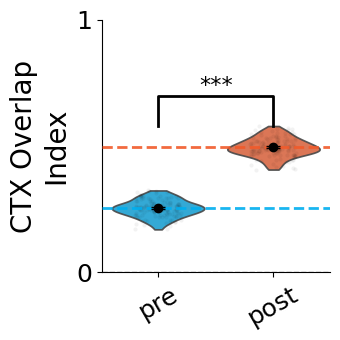

In [14]:
# Overlap index distributions (pre vs post consolidation)
region_to_plot = 'CTX'  # 'MTL' or 'CTX'

overlap_region_df = overlap_trial_df[overlap_trial_df['region'] == region_to_plot]

dist1 = (
    'pre',
    overlap_region_df.loc[overlap_region_df['phase'] == 'pre', 'overlap_index'].to_numpy(),
)
dist2 = (
    'post',
    overlap_region_df.loc[overlap_region_df['phase'] == 'post', 'overlap_index'].to_numpy(),
)

palette = {
    'pre': blue,
    'post': red,
}

compare_distributions_12(dist1, dist2, palette)
plt.tight_layout()
sns.despine()

plt.ylabel(f'{region_to_plot} Overlap\nIndex', fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([0, 1], fontsize=18)
plt.axhline(0.0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
sns.despine()


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


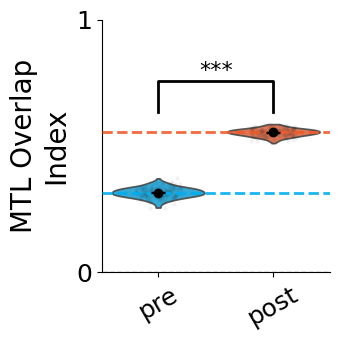

In [15]:
# Overlap index distributions (pre vs post consolidation)
region_to_plot = 'MTL'  # 'MTL' or 'CTX'

overlap_region_df = overlap_trial_df[overlap_trial_df['region'] == region_to_plot]

dist1 = (
    'pre',
    overlap_region_df.loc[overlap_region_df['phase'] == 'pre', 'overlap_index'].to_numpy(),
)
dist2 = (
    'post',
    overlap_region_df.loc[overlap_region_df['phase'] == 'post', 'overlap_index'].to_numpy(),
)

palette = {
    'pre': blue,
    'post': red,
}

compare_distributions_12(dist1, dist2, palette)
plt.tight_layout()
sns.despine()

plt.ylabel(f'{region_to_plot} Overlap\nIndex', fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([0, 1], fontsize=18)
plt.axhline(0.0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
sns.despine()

## 3) Synaptic Engrams I and II

TODO: add synaptic engram analysis.


In [16]:
# Synaptic engrams config + run
from copy import deepcopy
from network_parameters import network_parameters

seed_everything(0)

synaptic_engrams_config = {
    "seed": 0,
    "conditioning_day_length": 100,
    "conditioning_mean_duration": 5,
    "conditioning_num_swaps": 4,
    "extinction_days": 1000,
    "extinction_day_length": 20,
    "extinction_mean_duration": 5,
    "extinction_num_swaps": 4,
    "num_stability_seeds": 50,
    "record_rate_activity": 1,
    "fear_probe_fraction": 0.25,
}

synaptic_results = run_synaptic_engrams_experiment(
    network_parameters=deepcopy(network_parameters),
    **synaptic_engrams_config,
)

synaptic_network = synaptic_results["network"]
synaptic_summary_df = synaptic_results["summary_df"]
display(synaptic_summary_df)

synaptic_plot_data = synaptic_results["plot_data"]


,metric,value
0,ctx_EE_mean,0.013082
1,ctx_ENE_mean,0.001263
2,mtl_sem_to_ctx_E_mean,0.018975
3,mtl_sem_to_ctx_NE_mean,0.000641
4,ctx_EE_post_extinction_mean,0.006975
5,ctx_ENE_post_extinction_mean,0.002137
6,fear_input_last,0.022522
7,stability_savings_mean,1.000000
8,stability_naive_mean,0.446000


Text(0.5, 0, 'Time')

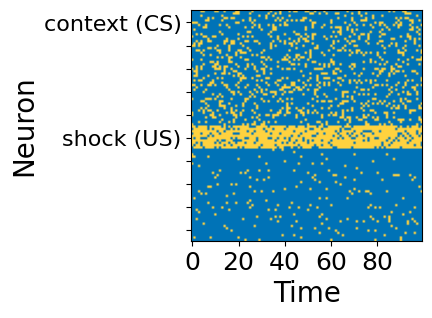

In [17]:
# Plot 1: MTL activity during conditioning day
fig = plt.figure(figsize=(3, 3))

plt.imshow(synaptic_plot_data["mtl_conditioning"][:, :100].T, cmap=blue_yellow, vmin=0, vmax=1)

# Example parameters
N = 100  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"context (CS)" if i == 0 else "" for i in range(NA)]
labels_B = [f"shock (US)" if i == 0 else "" for i in range(NA)]
labels = labels_A + labels_B

# Positions for labels (centered in each segment)
positions = [M * (i + 0.5) for i in range(NA + NB)]
plt.yticks(positions, labels, fontsize=16)
plt.xticks([0, 20, 40, 60, 80], fontsize=18)
plt.ylabel("Neuron", fontsize=20)
plt.xlabel("Time", fontsize=20)


Text(0.5, 0, 'Time')

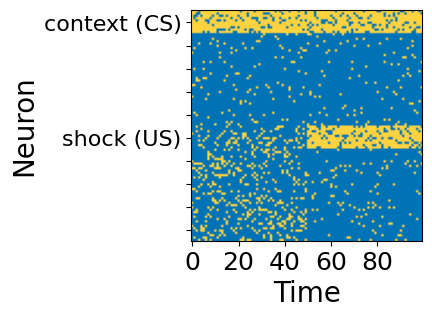

In [18]:
# Plot 2: MTL activity during recall day
fig = plt.figure(figsize=(3, 3))

plt.imshow(synaptic_plot_data["mtl_recall"][:, :100].T, cmap=blue_yellow, vmin=0, vmax=1)

# Example parameters
N = 100  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"context (CS)" if i == 0 else "" for i in range(NA)]
labels_B = [f"shock (US)" if i == 0 else "" for i in range(NA)]
labels = labels_A + labels_B

# Positions for labels (centered in each segment)
positions = [M * (i + 0.5) for i in range(NA + NB)]
plt.yticks(positions, labels, fontsize=16)
plt.xticks([0, 20, 40, 60, 80], fontsize=18)
plt.ylabel("Neuron", fontsize=20)
plt.xlabel("Time", fontsize=20)


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


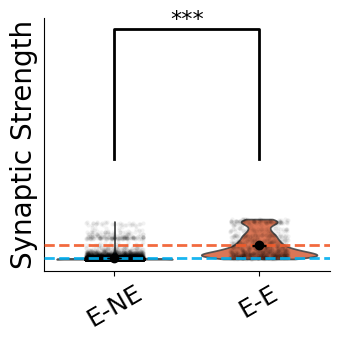

In [19]:
# Plot 3: CTX synaptic strengths (engram-engram vs non-engram-engram)
dist2 = ('E-E', synaptic_results['synaptic_distributions']['ctx_EE'])
dist1 = ('E-NE', synaptic_results['synaptic_distributions']['ctx_ENE'])

palette = {
    "E-NE": blue,
    "E-E": red
}

compare_distributions_12(dist1, dist2, palette)
plt.tight_layout()
sns.despine()

plt.ylabel("Synaptic Strength", fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([], fontsize=18)
plt.tight_layout()
sns.despine()


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


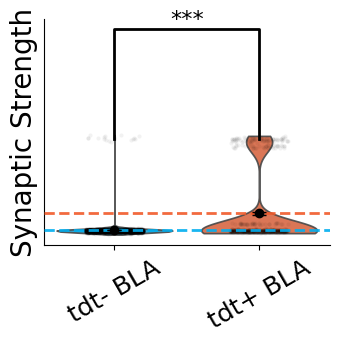

In [20]:
# Plot 4: MTL-semantic -> CTX engram synapses
dist1 = ('tdt- BLA', synaptic_results['synaptic_distributions']['mtl_sem_to_ctx_NE'])
dist2 = ('tdt+ BLA', synaptic_results['synaptic_distributions']['mtl_sem_to_ctx_E'])

palette = {
    "tdt+ BLA": red, 
    "tdt- BLA": blue
}

compare_distributions_12(dist1, dist2, palette)
plt.tight_layout()
sns.despine()

plt.ylabel("Synaptic Strength", fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([], fontsize=18)
plt.tight_layout()
sns.despine()


Text(0.5, 0, 'Time')

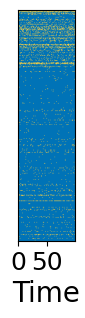

In [21]:
# Plot 5: CTX activity during conditioning day
fig = plt.figure(figsize=(3, 3))

plt.imshow(synaptic_plot_data["ctx_conditioning"].T, cmap=blue_yellow, vmin=0, vmax=1)

# Example parameters
N = 100  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B

# Positions for labels (centered in each segment)
positions = [M * (i + 0.5) for i in range(NA + NB)]
plt.yticks([])
plt.xticks([0, 50], fontsize=18)
#plt.ylabel("Neuron", fontsize=20)
plt.xlabel("Time", fontsize=20)


Text(0.5, 0, 'Time')

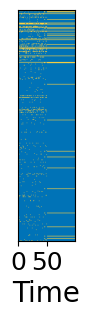

In [22]:
# Plot 6: CTX activity during recall day
fig = plt.figure(figsize=(3, 3))

plt.imshow(synaptic_plot_data["ctx_recall"].T, cmap=blue_yellow, vmin=0, vmax=1)

# Example parameters
N = 100  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B

# Positions for labels (centered in each segment)
positions = [M * (i + 0.5) for i in range(NA + NB)]
plt.yticks([])
plt.xticks([0, 50], fontsize=18)
#plt.ylabel("Neuron", fontsize=20)
plt.xlabel("Time", fontsize=20)


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


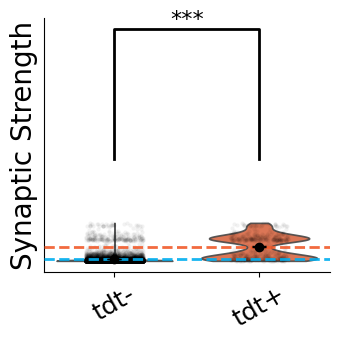

In [23]:
# Plot 7: Recall-only CTX cells -> CTX engram cells
dist1 =  ('tdt-', synaptic_results['synaptic_distributions']['ctx_ENE'])
dist2 = ('tdt+', synaptic_results['synaptic_distributions']['ctx_recall_to_ctx_E'])

palette = {
    "tdt-": blue, 
    "tdt+": red
}

compare_distributions_12(dist1, dist2, palette)
plt.tight_layout()
sns.despine()


plt.ylabel("Synaptic Strength", fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([], fontsize=18)
plt.tight_layout()
sns.despine()


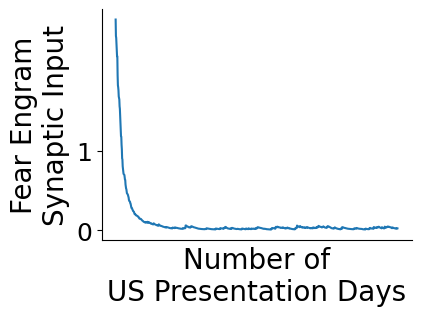

In [24]:
# Plot 8: Fear engram synaptic input across extinction
fear_input = synaptic_results['fear_input'].detach().cpu().numpy()
fig = plt.figure(figsize=(4, 3))

plt.plot(fear_input)
plt.xlabel("Number of\nUS Presentation Days", fontsize=20)
plt.ylabel("Fear Engram\nSynaptic Input", fontsize=20)
plt.xticks([])
plt.yticks([0, 1], fontsize=18)
sns.despine()


Text(0.5, 0, 'Time')

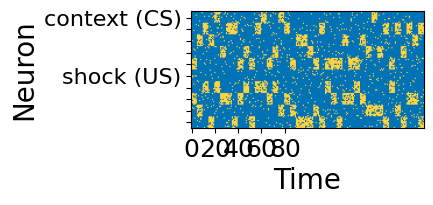

In [25]:
# Plot 9: MTL activity during late extinction
fig = plt.figure(figsize=(3, 3))

plt.imshow(synaptic_plot_data["mtl_late_extinction"][:, :100].T, cmap=blue_yellow, vmin=0, vmax=1)

# Example parameters
N = 100  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"context (CS)" if i == 0 else "" for i in range(NA)]
labels_B = [f"shock (US)" if i == 0 else "" for i in range(NA)]
labels = labels_A + labels_B

# Positions for labels (centered in each segment)
positions = [M * (i + 0.5) for i in range(NA + NB)]
plt.yticks(positions, labels, fontsize=16)
plt.xticks([0, 20, 40, 60, 80], fontsize=18)
plt.ylabel("Neuron", fontsize=20)
plt.xlabel("Time", fontsize=20)


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


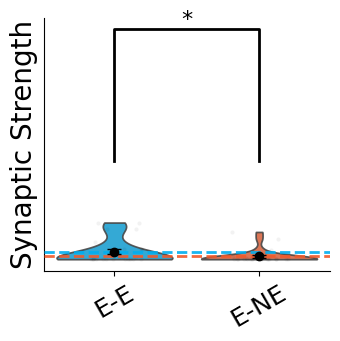

In [26]:
# Plot 10: Post-extinction CTX synaptic strengths (engram-engram vs non-engram-engram)
dist1 = ('E-E', synaptic_results['synaptic_distributions_post_extinction_sampled']['ctx_EE'])
dist2 = ('E-NE', synaptic_results['synaptic_distributions_post_extinction_sampled']['ctx_ENE'])

palette = {
    "E-NE": red, 
    "E-E": blue
}

compare_distributions_12(dist1, dist2, palette)
plt.tight_layout()
sns.despine()


plt.ylabel("Synaptic Strength", fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([], fontsize=18)
plt.tight_layout()
sns.despine()


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


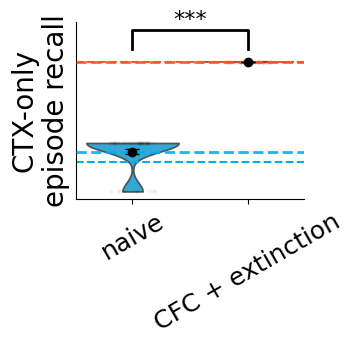

In [27]:
# Plot 11: CTX-only episode recall (savings vs naive)
dist2 = ('CFC + extinction', synaptic_results['stability_savings'].detach().cpu().numpy())
dist1 = ('naive', synaptic_results['stability_naive'].detach().cpu().numpy())

palette = {
    "CFC + extinction": red, 
    "naive": blue
}

compare_distributions_12(dist1, dist2, palette)
plt.tight_layout()
sns.despine()


plt.ylabel("CTX-only\nepisode recall", fontsize=20)
plt.axhline(0.38, color=blue, linestyle='--')
plt.axhline(1, color=red, linestyle='--')
plt.xticks(fontsize=18, rotation=30)
plt.yticks([], fontsize=18)
plt.tight_layout()
sns.despine()
